# Derivatives & the Component Database — Milestone 12

Equilibrium is only half the story. A downstream **staged-separation** library (distillation columns, absorbers) needs more than *where* phases split — it needs how fast the split **moves** when temperature or pressure change, and how much **heat** each stage carries. This milestone (vle-thermo 0.9.0) adds the machinery for that:

1. an expanded **24-compound database** carrying ideal-gas $C_p^\circ$ coefficients, now readable from Rust *and* Python;
2. **exact** temperature/pressure derivatives of fugacity and K-values — $\partial\ln\hat\varphi_i/\partial T$, $\partial\ln K_i/\partial T$, … — by dual-number automatic differentiation, never finite differences;
3. **real-mixture heat capacity** $C_p$ and **partial molar enthalpy** $\bar H_i$.

Derivative identities follow Michelsen & Mollerup (26); the dual-number AD follows Rehner & Bauer (27); property data is Poling, Prausnitz & O'Connell 5th ed. (30).

## Setup (optional)

The cell below is **commented out by default**. Uncomment it if you want to use the latest `vle-thermo` released on PyPI instead of whatever version is currently installed in your kernel.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context from the research paper

The K-value is the ratio the whole VLE calculation turns on. From [Chapter II §2.3](../docs/en/research-paper/chapter-2-vle-theory.md) the two-model framework writes it two ways:

- **φ-φ** (equation of state on both phases): $K_i = \hat\varphi_i^{\,L} / \hat\varphi_i^{\,V}$.
- **γ-φ** (activity-model liquid): modified Raoult, $K_i = \dfrac{\gamma_i\, P_i^{\text{sat}}\, \varphi_i^{\text{sat}}\, \text{POY}_i}{\hat\varphi_i^{\,V}\, P}$.

Both are built from the fugacity coefficient $\hat\varphi_i$. So the *derivatives* of $K_i$ decompose the same way — and the exact residual enthalpy follows from the Gibbs–Helmholtz relation

$$\sum_i x_i\,\frac{\partial \ln\hat\varphi_i}{\partial T} = -\frac{H^R}{RT^2},$$

which this notebook uses as a correctness check. The heat-capacity and enthalpy definitions are the departure-function framework of the same chapter.

## What was built in this milestone

In the Rust engine (all exposed through `vle.System` and `vle.components`):

- **`vle.components`** — 24 compounds with `cp_coeffs` ($C_p^\circ/R$ polynomial), plus a byte-identical Rust-side copy (`vle_thermo::db`).
- **`System.d_ln_phi_d_t` / `d_ln_phi_d_p`** — exact $\partial\ln\hat\varphi_i/\partial T$ [1/K], $\partial\ln\hat\varphi_i/\partial P$ [1/kPa].
- **`System.k_values_with_derivs`** — $(K_i,\ \partial\ln K_i/\partial T,\ \partial\ln K_i/\partial P)$.
- **`System.phase_cp`** — real-mixture $C_p$ [kJ/(kmol·K)].
- **`System.partial_molar_enthalpy`** — $\bar H_i$ [kJ/kmol], with $\sum_i x_i \bar H_i = H$.

The derivatives are computed by evaluating the *same* fugacity code with dual numbers, so they are exact to machine precision (27).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from vle import System, components
from vle.units import Q_

print('bundled compounds:', len(components.available()))

bundled compounds: 24


## 1. A tour of the 24-compound database

The database grew from 15 to 24 compounds and now ships ideal-gas heat-capacity coefficients. The `cp_coeffs` are the **dimensionless** $C_p^\circ/R = \sum_k a_k T^k$ polynomial (T in K), matching the engine convention exactly. Below we read toluene — the benzene–toluene pair is *the* teaching binary for distillation.

In [3]:
tol = components.get('toluene')
print(f'toluene  Tc={tol.tc} K  Pc={tol.pc} kPa  omega={tol.omega}')
print('cp_coeffs (Cp0/R poly):', tol.cp_coeffs)

# Evaluate Cp0(298.15 K) from the polynomial and compare to literature
R = 8.31451  # kJ/(kmol.K)
T0 = 298.15
cp0 = R * sum(a * T0**k for k, a in enumerate(tol.cp_coeffs))
# kJ/(kmol.K) is numerically identical to J/(mol.K).
print(f'Cp0(298.15 K) = {cp0:.2f} kJ/(kmol.K)  (~103.7 J/(mol.K) lit.)')
assert abs(cp0 - 103.7) / 103.7 < 0.02  # within 2%

toluene  Tc=591.75 K  Pc=4126.3 kPa  omega=0.2657
cp_coeffs (Cp0/R poly): [3.865977968849799, 0.0035579797240465165, 0.00013355923888245565, -1.8658893668072264e-07, 7.689956177044637e-11]
Cp0(298.15 K) = 103.61 kJ/(kmol.K)  (~103.7 J/(mol.K) lit.)


## 2. K(T) and its exact tangent — the money shot

For a benzene–toluene liquid we plot $\ln K_{\text{benzene}}$ over a temperature band, then draw the **tangent** predicted by the exact derivative $\partial\ln K/\partial T$ at the mid-point. If the derivative is right, the tangent kisses the curve.

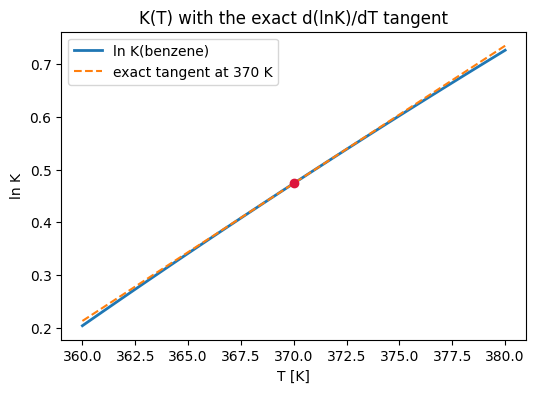

exact d(lnK)/dT = 2.608183e-02   FD = 2.608189e-02


In [4]:
sys = System(['benzene', 'toluene'], eos='PR')
p = 101.325  # kPa
x = [0.5, 0.5]
y = [0.7, 0.3]  # trial vapor

Ts = np.linspace(360.0, 380.0, 41)
lnK0 = np.array([np.log(sys.k_values(T, p, x, y)[0]) for T in Ts])

# Exact derivative at the mid-point.
Tmid = 370.0
k, dlnk_dt, dlnk_dp = sys.k_values_with_derivs(Tmid, p, x, y)
lnKmid = np.log(k[0])
tangent = lnKmid + dlnk_dt[0] * (Ts - Tmid)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ts, lnK0, label='ln K(benzene)', lw=2)
ax.plot(Ts, tangent, '--', label='exact tangent at 370 K')
ax.plot([Tmid], [lnKmid], 'o', color='crimson')
ax.set_xlabel('T [K]'); ax.set_ylabel('ln K'); ax.legend()
ax.set_title('K(T) with the exact d(lnK)/dT tangent')
plt.show()

# Pin: the exact derivative must match a central difference.
h = 0.5
fd = (np.log(sys.k_values(Tmid + h, p, x, y)[0])
      - np.log(sys.k_values(Tmid - h, p, x, y)[0])) / (2 * h)
print(f'exact d(lnK)/dT = {dlnk_dt[0]:.6e}   FD = {fd:.6e}')
assert abs(dlnk_dt[0] - fd) < 1e-5 * abs(dlnk_dt[0])

## 3. Real-mixture heat capacity vs temperature

`phase_cp` returns $C_p = \sum_i x_i C_{p,i}^\circ + C_p^R$: the ideal-gas mixture value plus the residual from the EOS (computed with a *second-order* dual). We compare the vapor's real $C_p$ against the ideal-gas part over a temperature sweep at a moderate pressure.

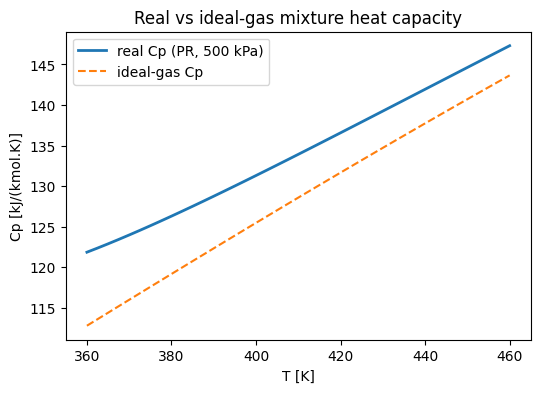

Cp^R at 400 K: 5.839663422040189


In [5]:
sysv = System(['benzene', 'toluene'], eos='PR')
xv = [0.5, 0.5]
P = 500.0  # kPa
Ts = np.linspace(360.0, 460.0, 41)
cp_real = np.array([sysv.phase_cp(T, P, xv, 'vapor') for T in Ts])

# Ideal-gas part from the bundled cp_coeffs.
def cp_ideal(T):
    tot = 0.0
    for name, xi in zip(['benzene', 'toluene'], xv):
        c = components.get(name).cp_coeffs
        tot += xi * R * sum(a * T**k for k, a in enumerate(c))
    return tot
cp_id = np.array([cp_ideal(T) for T in Ts])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ts, cp_real, label='real Cp (PR, 500 kPa)', lw=2)
ax.plot(Ts, cp_id, '--', label='ideal-gas Cp')
ax.set_xlabel('T [K]'); ax.set_ylabel('Cp [kJ/(kmol.K)]'); ax.legend()
ax.set_title('Real vs ideal-gas mixture heat capacity')
plt.show()

# The residual Cp^R = real - ideal is positive here (attractive EOS).
print('Cp^R at 400 K:', sysv.phase_cp(400.0, P, xv, 'vapor') - cp_ideal(400.0))

## 4. Partial molar enthalpy and the Euler check

The partial molar enthalpies must sum back to the total: $\sum_i x_i \bar H_i = H$. This is Euler's theorem for the homogeneous-degree-1 enthalpy, and it is a hard invariant — we assert it below and draw the per-component bars.

sum x_i Hbar_i = 8080.222   H = 8080.222 kJ/kmol


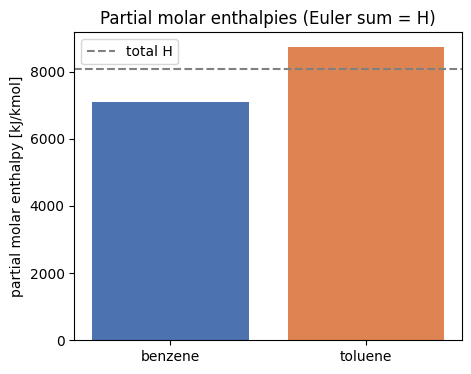

In [6]:
sysh = System(['benzene', 'toluene'], eos='PR')
T, P = 380.0, 300.0
xh = [0.4, 0.6]
hbar = sysh.partial_molar_enthalpy(T, P, xh, 'vapor')
H_total, _S = sysh.enthalpy_entropy(T, P, xh, 'vapor')
euler = sum(xi * hi for xi, hi in zip(xh, hbar))
print(f'sum x_i Hbar_i = {euler:.3f}   H = {H_total:.3f} kJ/kmol')
assert abs(euler - H_total) < 1e-6 * abs(H_total)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['benzene', 'toluene'], hbar, color=['#4C72B0', '#DD8452'])
ax.axhline(H_total, ls='--', color='gray', label='total H')
ax.set_ylabel('partial molar enthalpy [kJ/kmol]'); ax.legend()
ax.set_title('Partial molar enthalpies (Euler sum = H)')
plt.show()

## Exercises

### Exercise 1 — the pressure derivative identity

The composition-summed pressure derivative obeys an exact identity:

$$\sum_i x_i \frac{\partial \ln\hat\varphi_i}{\partial P} = \frac{Z - 1}{P}.$$

Verify it for the benzene–toluene vapor at (400 K, 800 kPa, x = [0.5, 0.5]) using `d_ln_phi_d_p` and `z_factor`.

In [7]:
# TODO: build the System, evaluate d_ln_phi_d_p and z_factor,
# and check the identity holds to ~1e-9.
sys_ex = System(['benzene', 'toluene'], eos='PR')
# dp = sys_ex.d_ln_phi_d_p(...)
# z = sys_ex.z_factor(...)
# lhs = ...; rhs = ...


<details>
<summary>Solution</summary>

```python
sys_ex = System(['benzene', 'toluene'], eos='PR')
T, P, x = 400.0, 800.0, [0.5, 0.5]
dp = sys_ex.d_ln_phi_d_p(T, P, x, 'vapor')
z = sys_ex.z_factor(T, P, x, 'vapor')
lhs = sum(xi * di for xi, di in zip(x, dp))
rhs = (z - 1.0) / P
print(lhs, rhs)
assert abs(lhs - rhs) < 1e-9 * max(abs(rhs), 1e-9)
```
</details>

### Exercise 2 — condensation lowers the liquid enthalpy

Build a **γ-φ** methanol/water System (`liquid_model='activity'`, `activity='VanLaar'`, `vapor_model='ideal'`, `aij=[[0.0, 0.85], [0.52, 0.0]]`). Show that the liquid enthalpy is **below** the vapor enthalpy at (340 K, 100 kPa, x = [0.4, 0.6]) — the latent heat of condensation. (Before M12.4 this call errored, because the liquid has no cubic EOS.)

In [8]:
# TODO: build the gamma-phi System and compare liquid vs vapor enthalpy.
# sys_gp = System(['methanol', 'water'], liquid_model='activity', ...)


<details>
<summary>Solution</summary>

```python
sys_gp = System(['methanol', 'water'], liquid_model='activity',
                activity='VanLaar', vapor_model='ideal',
                aij=[[0.0, 0.85], [0.52, 0.0]])
T, P, x = 340.0, 100.0, [0.4, 0.6]
h_liq, _ = sys_gp.enthalpy_entropy(T, P, x, 'liquid')
h_vap, _ = sys_gp.enthalpy_entropy(T, P, x, 'vapor')
print('H_liquid =', h_liq, '  H_vapor =', h_vap)
assert h_liq < h_vap
```
</details>

## References

- Research paper: [Chapter II — VLE theory](../docs/en/research-paper/chapter-2-vle-theory.md) (K-values, departure functions).
- Parameter reference: [parameter_reference.md](../docs/en/parameters/parameter_reference.md) (the $C_p^\circ/R$ polynomials).
- Plan of record: `DERIVATIVE_RELEASE_PLAN.md` (Milestone 12 design, the T/P-generic core and dual-number strategy).
- (26) Michelsen & Mollerup — derivative identities; (27) Rehner & Bauer — dual-number AD; (30) Poling, Prausnitz & O'Connell — property data; (4) Da Silva & Báez (1989) — condensation-enthalpy path.

**Why this milestone exists:** a downstream staged-separation library consumes exactly these derivatives (stage-to-stage K sensitivity) and energy properties (reboiler/condenser duties). Shipping them here — exact and tested — means that library never has to finite-difference the engine.